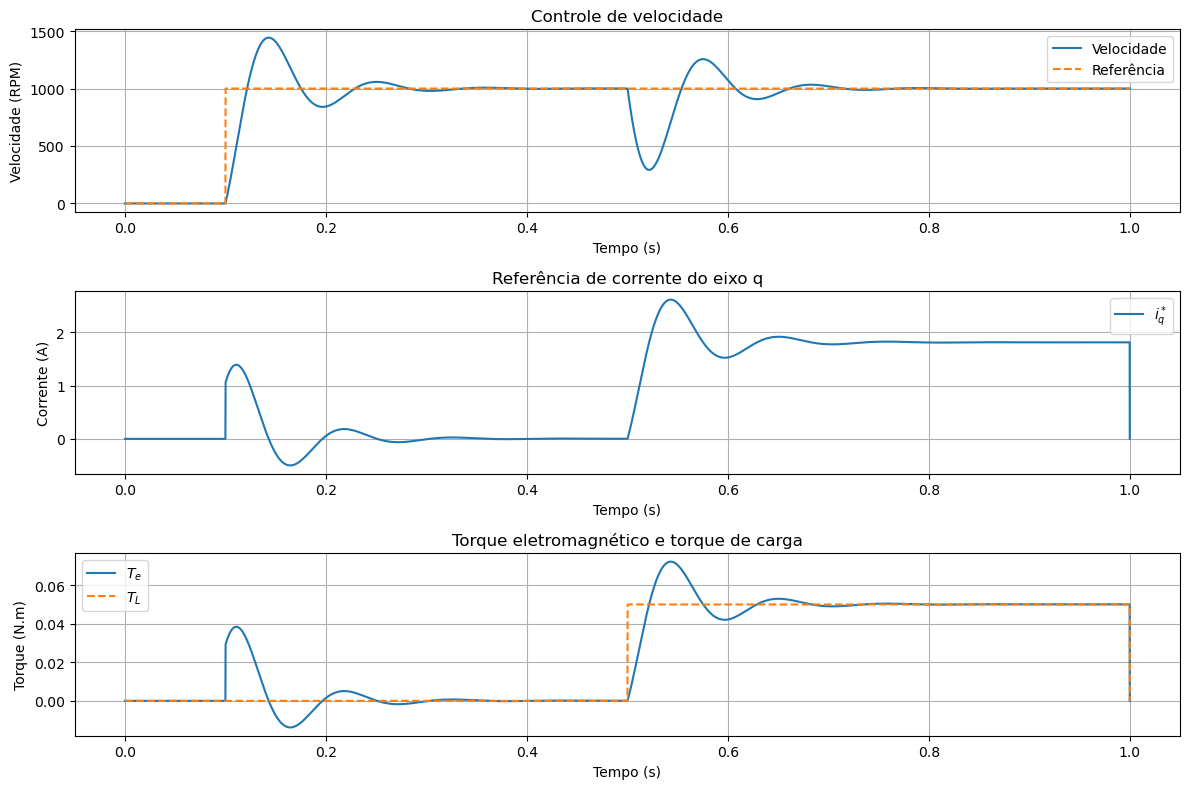

In [2]:
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt

from bldc import bldc, PIController


# ============================================================
# PARÂMETROS DO MOTOR
# ============================================================

Rs = 0.6
L = 5e-3

Ke = 0.0276
Kt = Ke

B = 7.312e-7
J = 7.312e-6

POLOS = 8
PARES_DE_POLOS = POLOS / 2

Vdc = 24


# ============================================================
# PARÂMETROS DA SIMULAÇÃO
# ============================================================

ti = 0.0
tf = 1.0
dt = 1e-4

N = int((tf - ti) / dt)

time = np.arange(ti, tf, dt)


# ============================================================
# REFERÊNCIA DE VELOCIDADE
# ============================================================

omega_ref_rpm = 1000

omega_ref = (
    omega_ref_rpm * 2*pi / 60
)


# ============================================================
# MOTOR
# ============================================================

motor = bldc(
    R=Rs,
    L=L,
    B=B,
    J=J,
    Ke=Ke,
    Kt=Kt,
    P=PARES_DE_POLOS,
    Vdc=Vdc
)


# ============================================================
# CONTROLADOR DE VELOCIDADE
# ============================================================

speed_controller = PIController(
    Kp=0.01,
    Ki=1.0,
    Ts=dt,

    # Saída do PI:
    # referência de corrente iq*
    output_min=-10,
    output_max=10
)


# ============================================================
# VARIÁVEIS DA SIMULAÇÃO
# ============================================================

omega = np.zeros(N)

iq_ref = np.zeros(N)

torque = np.zeros(N)

load_torque = np.zeros(N)


# ============================================================
# SIMULAÇÃO
# ============================================================

for k in range(N - 1):

    # --------------------------------------------------------
    # Referência de velocidade
    # --------------------------------------------------------

    if time[k] < 0.1:

        omega_ref_k = 0.0

    else:

        omega_ref_k = omega_ref


    # --------------------------------------------------------
    # Erro de velocidade
    # --------------------------------------------------------

    speed_error = (
        omega_ref_k - omega[k]
    )


    # --------------------------------------------------------
    # PI DE VELOCIDADE
    # --------------------------------------------------------

    iq_ref[k] = speed_controller.update(
        speed_error
    )


    # --------------------------------------------------------
    # MODELO SIMPLIFICADO DO TORQUE
    # --------------------------------------------------------
    #
    # Nesta primeira simulação, assumimos que o
    # controlador de corrente consegue fazer:
    #
    # iq = iq_ref
    #
    # Portanto:
    #
    # Te = Kt * iq
    #

    torque[k] = Kt * iq_ref[k]


    # --------------------------------------------------------
    # CARGA
    # --------------------------------------------------------

    if time[k] > 0.5:

        load_torque[k] = 0.05

    else:

        load_torque[k] = 0.0


    # --------------------------------------------------------
    # DINÂMICA MECÂNICA
    # --------------------------------------------------------

    domega = (
        torque[k]
        - load_torque[k]
        - B * omega[k]
    ) / J


    # --------------------------------------------------------
    # INTEGRAÇÃO
    # --------------------------------------------------------

    omega[k + 1] = (
        omega[k]
        + domega * dt
    )


# ============================================================
# CONVERSÃO PARA RPM
# ============================================================

omega_rpm = (
    omega * 60 / (2*pi)
)


# ============================================================
# GRÁFICOS
# ============================================================

plt.figure(figsize=(12, 8))


# ------------------------------------------------------------
# VELOCIDADE
# ------------------------------------------------------------

plt.subplot(311)

plt.plot(
    time,
    omega_rpm,
    label="Velocidade"
)

plt.plot(
    time,
    np.where(
        time < 0.1,
        0,
        omega_ref_rpm
    ),
    "--",
    label="Referência"
)

plt.title(
    "Controle de velocidade"
)

plt.xlabel("Tempo (s)")
plt.ylabel("Velocidade (RPM)")

plt.grid()
plt.legend()


# ------------------------------------------------------------
# REFERÊNCIA DE CORRENTE
# ------------------------------------------------------------

plt.subplot(312)

plt.plot(
    time,
    iq_ref,
    label=r"$i_q^*$"
)

plt.title(
    "Referência de corrente do eixo q"
)

plt.xlabel("Tempo (s)")
plt.ylabel("Corrente (A)")

plt.grid()
plt.legend()


# ------------------------------------------------------------
# TORQUE
# ------------------------------------------------------------

plt.subplot(313)

plt.plot(
    time,
    torque,
    label=r"$T_e$"
)

plt.plot(
    time,
    load_torque,
    "--",
    label=r"$T_L$"
)

plt.title(
    "Torque eletromagnético e torque de carga"
)

plt.xlabel("Tempo (s)")
plt.ylabel("Torque (N.m)")

plt.grid()
plt.legend()


plt.tight_layout()

plt.show()

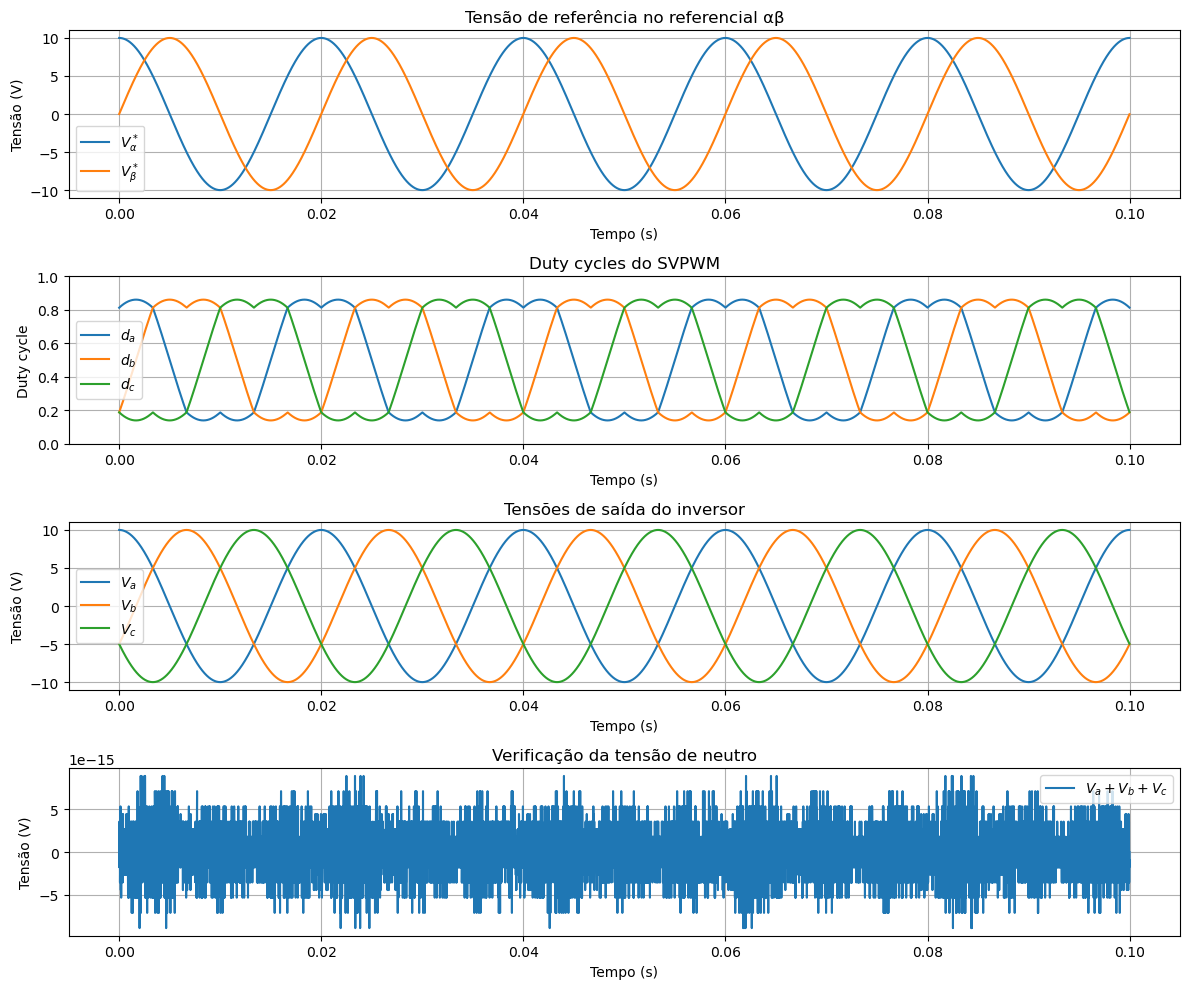

In [12]:
import importlib
import bldc

importlib.reload(bldc)

from bldc import Inverter, svpwm


# ============================================================
# PARÂMETROS
# ============================================================

Vdc = 24.0

f_ref = 50.0

omega_ref = 2 * np.pi * f_ref

Vref = 10.0

ti = 0.0
tf = 0.1

dt = 1e-5

time = np.arange(
    ti,
    tf,
    dt
)

N = len(time)


# ============================================================
# OBJETOS
# ============================================================

inverter = Inverter(
    Vdc=Vdc
)

svpwm1 = svpwm(
    Hz=10000,
    Vdc=24
)


# ============================================================
# VETORES DE REFERÊNCIA
# ============================================================

Valpha_ref = np.zeros(N)
Vbeta_ref = np.zeros(N)


# ============================================================
# DUTY CYCLES
# ============================================================

duty_a = np.zeros(N)
duty_b = np.zeros(N)
duty_c = np.zeros(N)


# ============================================================
# TENSÕES DE SAÍDA
# ============================================================

Va = np.zeros(N)
Vb = np.zeros(N)
Vc = np.zeros(N)


# ============================================================
# SIMULAÇÃO
# ============================================================

for k in range(N):

    t = time[k]

    # --------------------------------------------------------
    # Vetor espacial de tensão girante
    # --------------------------------------------------------

    theta = omega_ref * t

    Valpha_ref[k] = (
        Vref * np.cos(theta)
    )

    Vbeta_ref[k] = (
        Vref * np.sin(theta)
    )


    # --------------------------------------------------------
    # SVPWM
    # --------------------------------------------------------

    duty = svpwm1.modulate(
        Valpha_ref[k],
        Vbeta_ref[k]
    )

    duty_a[k] = duty[0]
    duty_b[k] = duty[1]
    duty_c[k] = duty[2]


    # --------------------------------------------------------
    # INVERSOR
    # --------------------------------------------------------

    Vabc = inverter.output_voltage(
        duty_a[k],
        duty_b[k],
        duty_c[k]
    )

    Va[k] = Vabc[0]
    Vb[k] = Vabc[1]
    Vc[k] = Vabc[2]

plt.figure(figsize=(12, 10))


# ============================================================
# TENSÕES DE REFERÊNCIA αβ
# ============================================================

plt.subplot(411)

plt.plot(
    time,
    Valpha_ref,
    label=r"$V_\alpha^*$"
)

plt.plot(
    time,
    Vbeta_ref,
    label=r"$V_\beta^*$"
)

plt.title(
    "Tensão de referência no referencial αβ"
)

plt.xlabel("Tempo (s)")
plt.ylabel("Tensão (V)")

plt.grid()
plt.legend()


# ============================================================
# DUTY CYCLES
# ============================================================

plt.subplot(412)

plt.plot(
    time,
    duty_a,
    label=r"$d_a$"
)

plt.plot(
    time,
    duty_b,
    label=r"$d_b$"
)

plt.plot(
    time,
    duty_c,
    label=r"$d_c$"
)

plt.title(
    "Duty cycles do SVPWM"
)

plt.xlabel("Tempo (s)")
plt.ylabel("Duty cycle")

plt.ylim(
    0,
    1
)

plt.grid()
plt.legend()


# ============================================================
# TENSÕES DE FASE
# ============================================================

plt.subplot(413)

plt.plot(
    time,
    Va,
    label=r"$V_a$"
)

plt.plot(
    time,
    Vb,
    label=r"$V_b$"
)

plt.plot(
    time,
    Vc,
    label=r"$V_c$"
)

plt.title(
    "Tensões de saída do inversor"
)

plt.xlabel("Tempo (s)")
plt.ylabel("Tensão (V)")

plt.grid()
plt.legend()


# ============================================================
# VERIFICAÇÃO DA SOMA DAS TENSÕES
# ============================================================

plt.subplot(414)

plt.plot(
    time,
    Va + Vb + Vc,
    label=r"$V_a+V_b+V_c$"
)

plt.title(
    "Verificação da tensão de neutro"
)

plt.xlabel("Tempo (s)")
plt.ylabel("Tensão (V)")

plt.grid()
plt.legend()


plt.tight_layout()

plt.show()